## API

In [1]:
import requests

In [2]:
# https://ru.wikipedia.org/wiki/Уравнение_Ван-дер-Ваальса
url = (
    "https://ru.wikipedia.org"
    "/api/rest_v1/page/html/"
    "Уравнение_Ван-дер-Ваальса"
)

In [4]:
response = requests.get(url)
response.text[:100]

'<!DOCTYPE html>\n<html prefix="dc: http://purl.org/dc/terms/ mw: http://mediawiki.org/rdf/" about="ht'

In [5]:
"table" in response.text

True

In [10]:
%pip install lxml

In [11]:
import pandas as pd

In [12]:
tables = pd.read_html(
    response.text, 
    decimal=",", 
    thousands=None,
)
tables[0]

<ipython-input-12-23a48896803d>:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(


,Вещество,"a, Па·м6·моль−2","b, 10−6 м3·моль−1"
0,Азот N2,0.13700,38.7
1,Аммиак NH3,0.42250,37.1
2,Аргон Ar,0.13550,32.0
3,Ацетилен C2H2,0.45160,52.2
4,Бром Br2,0.97500,59.1
5,Бромоводород HBr,0.45000,44.2
6,Бутан C4H10,1.38900,116.4
7,Вода H2O,0.55370,30.5
8,Водород H2,0.02452,26.5
9,Гексафторид серы SF6,0.78570,87.9


In [14]:
df = tables[0]

In [16]:
type(df)

pandas.core.frame.DataFrame

In [15]:
df.columns

Index(['Вещество', 'a,  Па·м6·моль−2', 'b,  10−6 м3·моль−1'], dtype='object')

In [17]:
# df.__getitem__("a,  Па·м6·моль−2")
df["a,  Па·м6·моль−2"]

0     0.13700
1     0.42250
2     0.13550
3     0.45160
4     0.97500
5     0.45000
6     1.38900
7     0.55370
8     0.02452
9     0.78570
10    0.00346
11    0.84600
12    0.13820
13    0.51930
14    0.41920
15    0.23030
16    0.02080
17    0.35700
18    0.14720
19    0.93900
20    0.68650
21    0.45440
22    0.36580
23    0.11710
24    0.95650
25    0.63430
26    0.37000
27    1.12900
28    0.55800
29    0.46120
Name: a,  Па·м6·моль−2, dtype: float64

In [18]:
df["a,  Па·м6·моль−2"].mean

<bound method Series.mean of 0     0.13700
1     0.42250
2     0.13550
3     0.45160
4     0.97500
5     0.45000
6     1.38900
7     0.55370
8     0.02452
9     0.78570
10    0.00346
11    0.84600
12    0.13820
13    0.51930
14    0.41920
15    0.23030
16    0.02080
17    0.35700
18    0.14720
19    0.93900
20    0.68650
21    0.45440
22    0.36580
23    0.11710
24    0.95650
25    0.63430
26    0.37000
27    1.12900
28    0.55800
29    0.46120
Name: a,  Па·м6·моль−2, dtype: float64>

In [19]:
df["a,  Па·м6·моль−2"].mean()

np.float64(0.48925933333333327)

In [20]:
df["a,  Па·м6·моль−2"].sum()

np.float64(14.677779999999998)

In [22]:
df["a,  Па·м6·моль−2"].mean(), df["a,  Па·м6·моль−2"].sum()

(np.float64(0.48925933333333327), np.float64(14.677779999999998))

In [24]:
type(4), type(4.0), 4 == 4.0

(int, float, True)

In [23]:
print(df["a,  Па·м6·моль−2"].mean())
print(df["a,  Па·м6·моль−2"].sum())

0.48925933333333327
14.677779999999998


<Axes: >

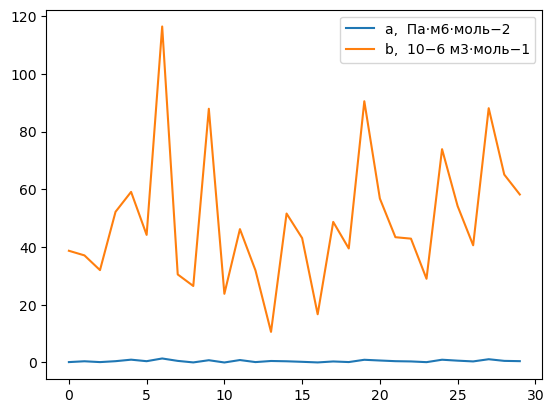

In [26]:
df.plot()

In [27]:
df.set_index("Вещество")

,"a, Па·м6·моль−2","b, 10−6 м3·моль−1"
Вещество,,
Азот N2,0.13700,38.7
Аммиак NH3,0.42250,37.1
Аргон Ar,0.13550,32.0
Ацетилен C2H2,0.45160,52.2
Бром Br2,0.97500,59.1
Бромоводород HBr,0.45000,44.2
Бутан C4H10,1.38900,116.4
Вода H2O,0.55370,30.5
Водород H2,0.02452,26.5


<Axes: xlabel='Вещество'>

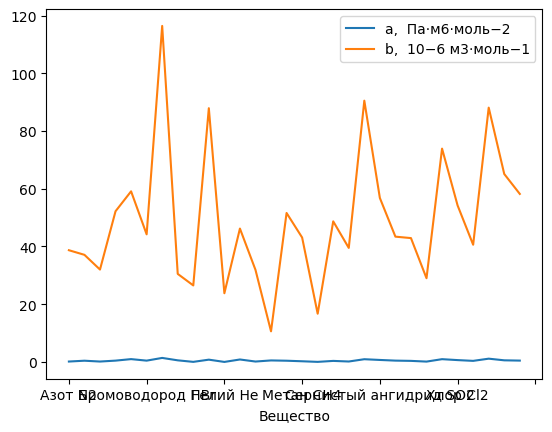

In [28]:
df.set_index("Вещество").plot()

<Axes: xlabel='Вещество'>

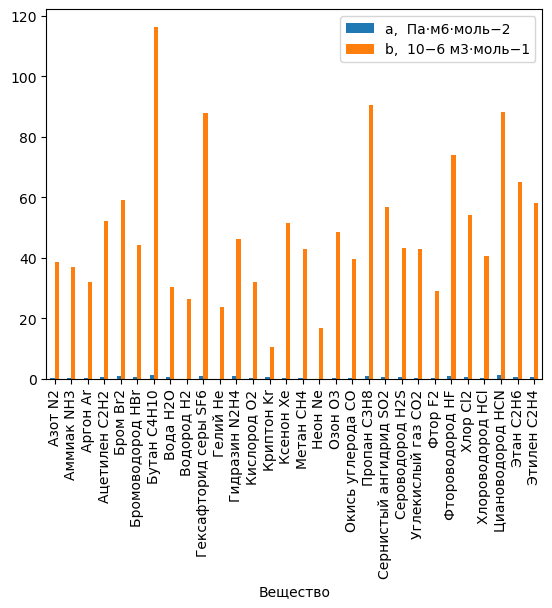

In [29]:
df.set_index("Вещество").plot(kind="bar")

<Axes: ylabel='Frequency'>

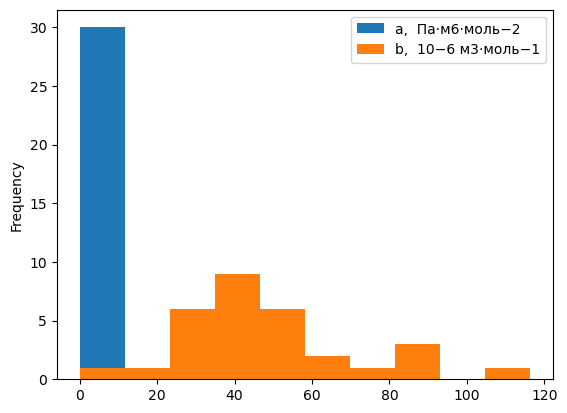

In [31]:
df.set_index("Вещество").plot(kind="hist")

<Axes: ylabel='Frequency'>

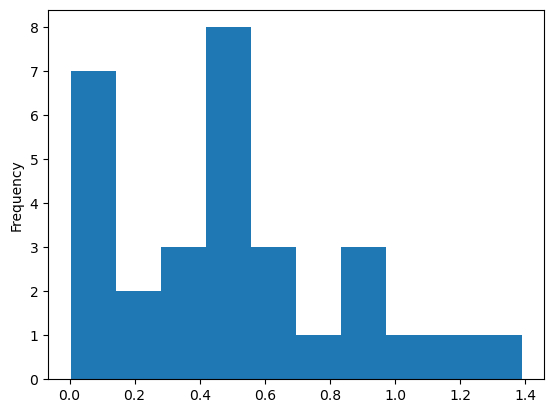

In [32]:
df.set_index("Вещество")["a,  Па·м6·моль−2"].plot(kind="hist")

In [34]:
df.head()

,Вещество,"a, Па·м6·моль−2","b, 10−6 м3·моль−1"
0,Азот N2,0.1370,38.7
1,Аммиак NH3,0.4225,37.1
2,Аргон Ar,0.1355,32.0
3,Ацетилен C2H2,0.4516,52.2
4,Бром Br2,0.9750,59.1


In [35]:
df.columns

Index(['Вещество', 'a,  Па·м6·моль−2', 'b,  10−6 м3·моль−1'], dtype='object')

In [38]:
df_sorted = df.sort_values(
    by=[
        "b,  10−6 м3·моль−1", 
        "a,  Па·м6·моль−2"
    ]
)
df_sorted.head()

,Вещество,"a, Па·м6·моль−2","b, 10−6 м3·моль−1"
13,Криптон Kr,0.51930,10.6
16,Неон Ne,0.02080,16.7
10,Гелий He,0.00346,23.8
8,Водород H2,0.02452,26.5
23,Фтор F2,0.11710,29.0


In [39]:
df_sorted.tail()

,Вещество,"a, Па·м6·моль−2","b, 10−6 м3·моль−1"
24,Фтороводород HF,0.9565,73.9
9,Гексафторид серы SF6,0.7857,87.9
27,Циановодород HCN,1.1290,88.1
19,Пропан C3H8,0.9390,90.5
6,Бутан C4H10,1.3890,116.4


In [43]:
df.sort_values(
    by=[
        "b,  10−6 м3·моль−1", 
        "a,  Па·м6·моль−2"
    ],
    ascending=False
).head()

,Вещество,"a, Па·м6·моль−2","b, 10−6 м3·моль−1"
6,Бутан C4H10,1.3890,116.4
19,Пропан C3H8,0.9390,90.5
27,Циановодород HCN,1.1290,88.1
9,Гексафторид серы SF6,0.7857,87.9
24,Фтороводород HF,0.9565,73.9


In [51]:
df["Вещество"].str.rsplit(" ", n=1).head()

0          [Азот, N2]
1       [Аммиак, NH3]
2         [Аргон, Ar]
3    [Ацетилен, C2H2]
4         [Бром, Br2]
Name: Вещество, dtype: object

In [52]:
df["Вещество"].str.rsplit(" ", n=1, expand=True).head()

,0,1
0,Азот,N2
1,Аммиак,NH3
2,Аргон,Ar
3,Ацетилен,C2H2
4,Бром,Br2


In [55]:
df["Вещество"].str.rsplit(" ", n=1, expand=True)\
    .rename(
        columns={
            0: "Name",
            1: "Formula"
        }
    ) \
    .head()

,Name,Formula
0,Азот,N2
1,Аммиак,NH3
2,Аргон,Ar
3,Ацетилен,C2H2
4,Бром,Br2
